### Setup and Functions

In [77]:
import xarray as xr
from astropy.time import Time
from sunpy.time import parse_time
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from astropy import constants as const

solar_radius = const.R_sun.value 
au = const.au.value  # Astronomical Unit in meters
k = const.k_B.value  # Boltzmann constant in J/K
c = const.c.value  # Speed of light in m/s
h = const.h.value  # Planck's constant in J*s
sigma = const.sigma_sb.value  # 5.6704e-8 W/m²/K⁴



np.float64(149597870700.0)

In [24]:
ds = xr.open_dataset("data/sorce_sim_L3_c24h_0240nm_2413nm_20030414_20200225.nc")

t = Time(ds["time"].values, format="jd")
ds["time"] = ("time", t.to_datetime())

df = ds.to_dataframe().reset_index('wavelength')
print(df.head())

                     wavelength  irradiance  uncertainty  quality
time                                                             
2003-04-14 12:00:00  240.020004    0.041338     0.000399       64
2003-04-14 12:00:00  240.110001    0.042611     0.000403       64
2003-04-14 12:00:00  240.190002    0.043288     0.000405       64
2003-04-14 12:00:00  240.279999    0.042863     0.000409       64
2003-04-14 12:00:00  240.369995    0.041678     0.000412       64


# Parcial 1

## Context of Data

In [25]:
ds.attrs

{'title': 'SORCE-SIM SSI (Solar Spectral Irradiance) V27',
 'version': 'V01.01',
 'file_version': 'V01.05',
 'time_cadence': '24 hour',
 'institution': 'Laboratory for Atmospheric and Space Physics, University of Colorado - Boulder',
 'date_created': 'Wed Apr  7 03:40:08 2021 UTC',
 'time_coverage_start_jd': '2452744.000000',
 'time_coverage_end_jd': '2458905.000000',
 'contributor_name': 'Steven Penton (steven.penton@lasp.colorado.edu)',
 'history': 'This file was created after the conclusion of the SORCE mission. This is data version 01 of the SIM data. The version of this file is V01.05 . File versions greater than V01.04 use double precision for irradiance.',
 'DOI': 'https://doi.org/10.5067/LDDKZ3PXZZ5G'}

In [26]:
start_time = parse_time(ds.attrs['time_coverage_start_jd'],format='jd')
end_time = parse_time(ds.attrs['time_coverage_end_jd'],format='jd')

print(f"Data covers from {start_time.iso} to {end_time.iso}")

Data covers from 2003-04-14 12:00:00.000 to 2020-02-25 12:00:00.000


The data covers 24h intervals, because of this the 27 of octover of 2006 is selected to be analized

In [27]:
selected_time = '2006-10-27 12:00:00'
selected_time_jd = Time(selected_time).jd
print('julian day:', selected_time_jd)

julian day: 2454036.0


In [28]:
data = df.loc['2006-10-27 12:00:00'].reset_index(drop=True).copy()
data.describe()

,wavelength,irradiance,uncertainty,quality
count,1235.000000,1235.000000,1235.000000,1235.000000
mean,552.826599,0.752969,0.000625,0.017814
std,464.644928,0.636563,0.000628,0.187986
min,240.020004,0.035762,0.000062,0.000000
25%,276.305008,0.189553,0.000231,0.000000
50%,347.559998,0.605870,0.000339,0.000000
75%,581.569977,1.127360,0.000876,0.000000
max,2412.340088,2.104573,0.003037,2.000000


## theory

**Monochromatic flux** (called *irradiance* by the SORCE mission) is the energy per unit area 
per unit wavelength:

$$[F_\lambda] = \left[\frac{\text{W}}{\text{m}^2 \text{ nm}}\right]$$

**Specific intensity** $I_\lambda$ is the flux per steradian:

$$I_\lambda = \frac{F_\lambda}{\Omega_\odot} \quad \left[\frac{\text{W}}{\text{m}^2 \text{ sr nm}}\right]$$

where $\Omega_\odot = 2\pi (1-\cos \theta_{\odot})$ is the solid angle of the Sun for a given date.

**Planck's law** gives the specific intensity of a blackbody at temperature $T$:

$$B_\lambda(T) = \frac{2hc^2}{\lambda^5} \frac{1}{e^{hc/\lambda k_B T} - 1} 
\quad \left[\frac{\text{W}}{\text{m}^2 \text{ sr nm}}\right]$$

where $h = 6.626\times10^{-34}$ J s, $c = 3\times10^8$ m/s, 
and $k_B = 1.381\times10^{-23}$ J/K. Fitting $B_\lambda(T)$ to the observed 
$I_\lambda$ gives the **color temperature** $T_\text{color}$ of the Sun.

In [29]:
ds['irradiance'].attrs


{'units': 'W m-2 nm-1',
 'standard_name': 'Solar Spectral Irradiance (SSI)',
 'long_name': 'Solar Spectral Irradiace (W m-2 nm-1)'}

## 1. Grafique la función espectral flujo monocromático versus longitud de onda.

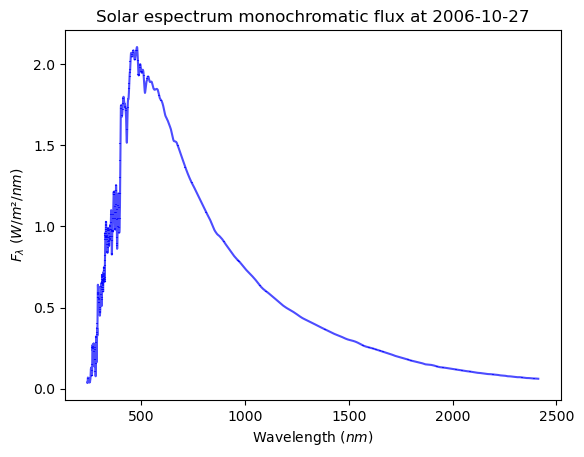

In [30]:
plt.errorbar(data['wavelength'], data['irradiance'], color='blue', alpha=0.7, yerr=data['uncertainty'])
plt.xlabel(r'Wavelength ($nm$)')
plt.ylabel(r'$F_\lambda$ ($W/m²/nm$)')
plt.title('Solar espectrum monochromatic flux at 2006-10-27')
plt.show()


note that the figure seems a lot a plank curve and also that the error reported is negible

## 2. Para la fecha dada, averigüe la distancia geocéntrica del Sol, así como el diámetro angular aparente del mismo, y calcule el ángulo sólido para la fecha.

acording to estellarium the sun had the folowing parameters

for 27-10-2006
appernt solar radius: 0°32'11.22''
distance to earth: 148672000  Km

also from stellarium is known

astronomical unit: 149597870.7 km (mean distance to sun)
solar diameter: 1392000 km

the effects of the position of the instrument of the SORCE mission are negible as it orbits at 569km and a 40.0° angle from earth rotacional axis with a perior of about 90 min, making any variation disapear on the avarage that the mission alredy do on the 24h interval

In [79]:
diameter_arcsec = 32 * 60 + 11.41
alpha_arcsec = diameter_arcsec / 2.0
alpha_rad = alpha_arcsec / 206265.0
Omega_sun = 2 * np.pi * (1 - np.cos(alpha_rad))



Omega_sun_calculated = np.pi * (solar_radius / au)**2

print(f"Solid angle (from angular diameter): {Omega_sun:.3e} sr")
print(f"Mean Solid angle (from solar radius and distance(1uA)): {Omega_sun_calculated:.3e} sr")


Solid angle (from angular diameter): 6.886e-05 sr
Mean Solid angle (from solar radius and distance(1uA)): 6.794e-05 sr


both values are close to each other which confirms the computacion, from now on the solid angle from the angular diameter of the sun will be use as it is more exact for the time periot

## 3. Represente en forma gráfica el espectro en términos de la intensidad específica versus longitud de onda.

In [32]:
data['specific_intensity'] = data['irradiance'] / Omega_sun
data['specific_intensity_error'] = data['uncertainty'] / Omega_sun

In [33]:
from utilities import plot_data

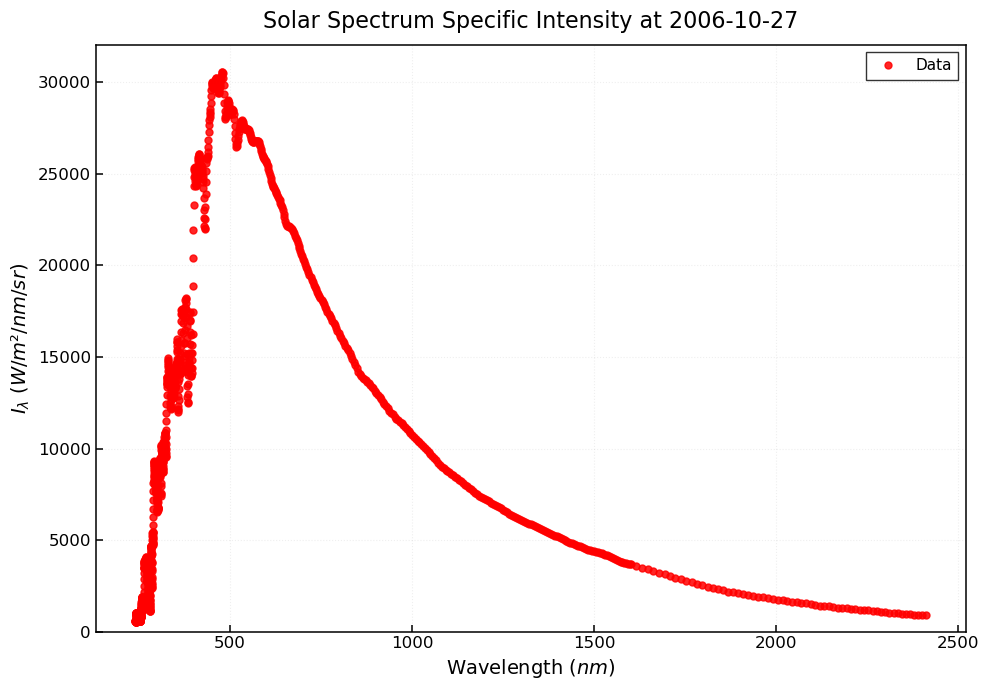

In [34]:
plot_data(
    dfs=[data],
    x_col='wavelength',
    y_col='specific_intensity',
    yerr=None,
    xlabel=r"Wavelength ($nm$)",
    ylabel=r"$I_\lambda$ ($W/m²/nm/sr$)",
    title='Solar Spectrum Specific Intensity at 2006-10-27',
    labels=['Data'],
    colors=['red'],
    title_fontsize=16,
    axis_label_fontsize=14,
    tick_fontsize=12,
    legend_fontsize=11,
    figure_dpi=100,
    figure_size=(10, 7),
    grid_alpha=0.2,
    legend_loc='best'
);

In [35]:
from utilities import blackbody_plot_with_temps


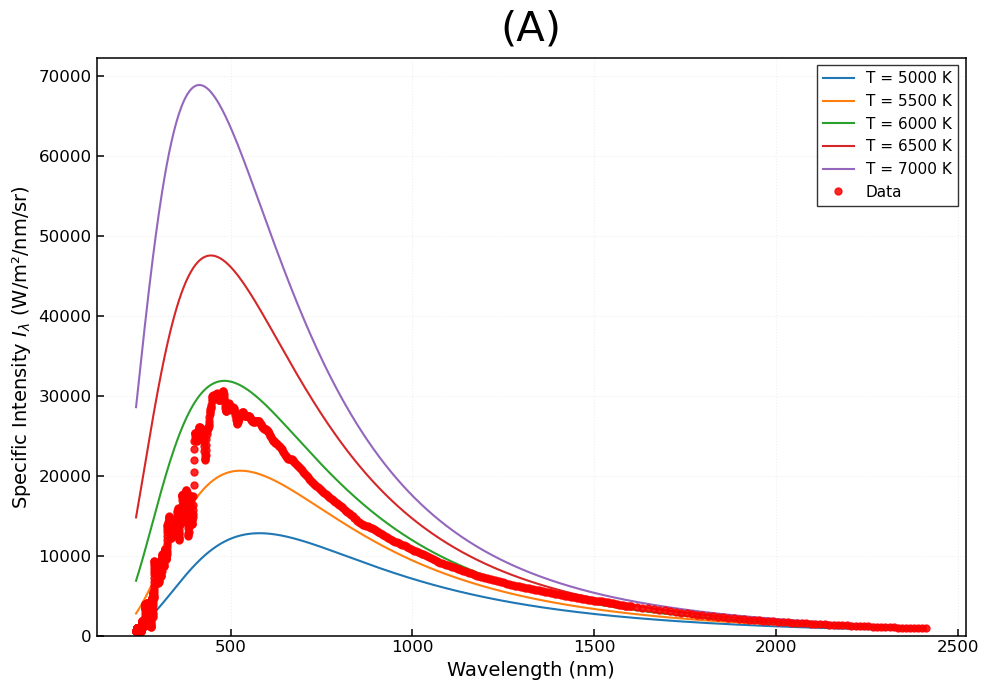

In [36]:
fig_1 = blackbody_plot_with_temps(
    dfs=[data],
    x_col='wavelength',
    y_col='specific_intensity',
    temp_params=[5000, 7000, 5],
    yerr=None,
    xlabel="Wavelength (nm)",
    ylabel=r"Specific Intensity $I_\lambda$ (W/m²/nm/sr)",
    title='(A)',
    labels=['Data'],
    colors=['red'],
    title_fontsize=30
);

## 4. Ajuste una curva de intensidad de Planck, la mejor posible, al espectro anterior (punto 3). La curva de Planck debe tener su máximo lo más cercano al máximo real, debe coincidir en al menos un punto antes del máximo y otro después del máximo. La temperatura de esta curva teórica se denomina la "temperatura de color" del astro, en nuestro caso el Sol.

/home/thomas/Desktop/Solar_espectrum_analisis/utilities.py:337: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


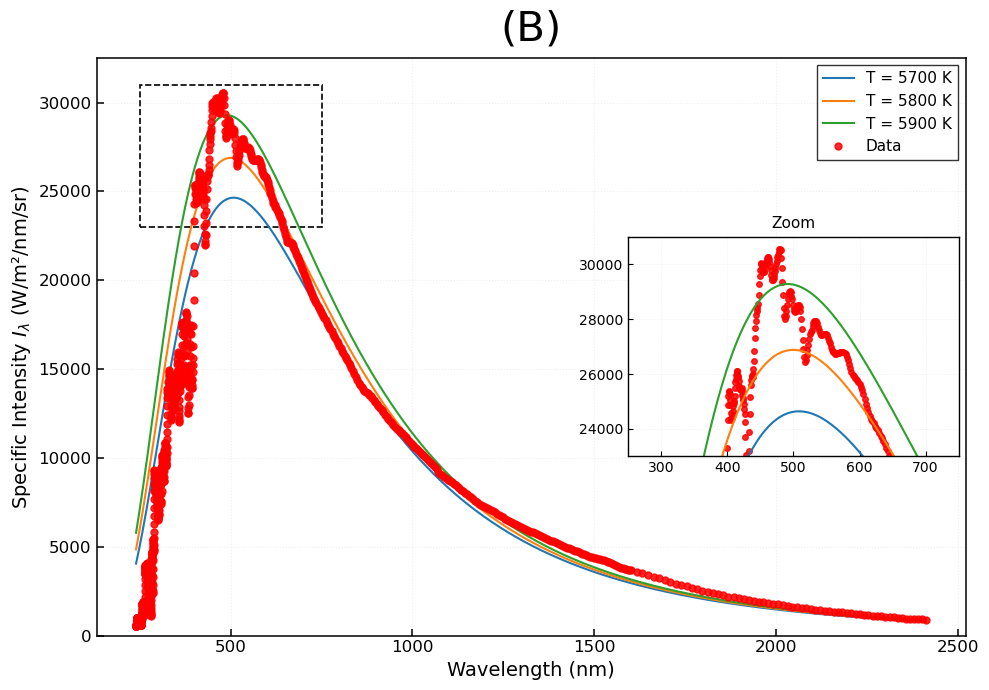

In [37]:
fig_2 = blackbody_plot_with_temps(
    dfs=[data],
    x_col='wavelength',
    y_col='specific_intensity',
    temp_params=[5700, 5900, 3],
    yerr=None,
    xlabel="Wavelength (nm)",
    ylabel=r"Specific Intensity $I_\lambda$ (W/m²/nm/sr)",
    title='(B)',
    labels=['Data'],
    colors=['red'],
    show_box_zoom=True,
    box=[(250,23000),( 750,31000)],
    legend_loc='upper right',
    title_fontsize=30

);

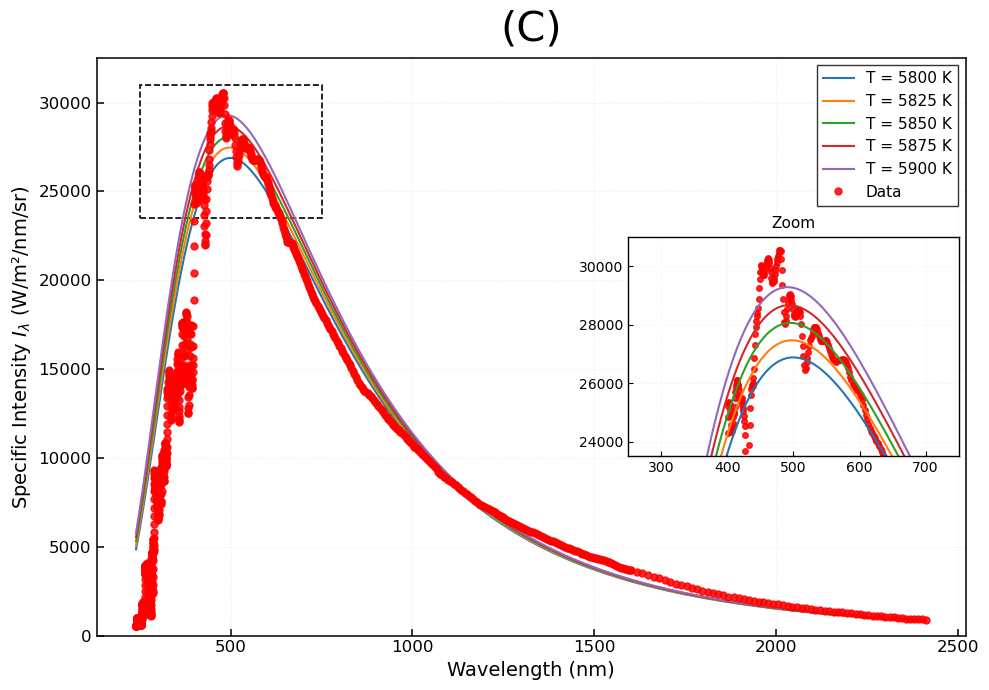

In [38]:
fig_3 = blackbody_plot_with_temps(
    dfs=[data],
    x_col='wavelength',
    y_col='specific_intensity',
    temp_params=[5800, 5900, 5],
    yerr=None,
    xlabel="Wavelength (nm)",
    ylabel=r"Specific Intensity $I_\lambda$ (W/m²/nm/sr)",
    title='(C)',
    labels=['Data'],
    colors=['red'],
    show_box_zoom=True,
    box=[(250,23500),( 750,31000)],
    title_fontsize=30
);

T = 5875K

it doesn't reach the top as a 5900K line would, but the line higher than 5900K doesn't touch a dot previus to the maximun

In [39]:
from utilities import blackbody_temperature_comparison_with_errors


--- Results for Data ---
Estimated temperature: 5875 ± 1 K
R²:                    0.691245


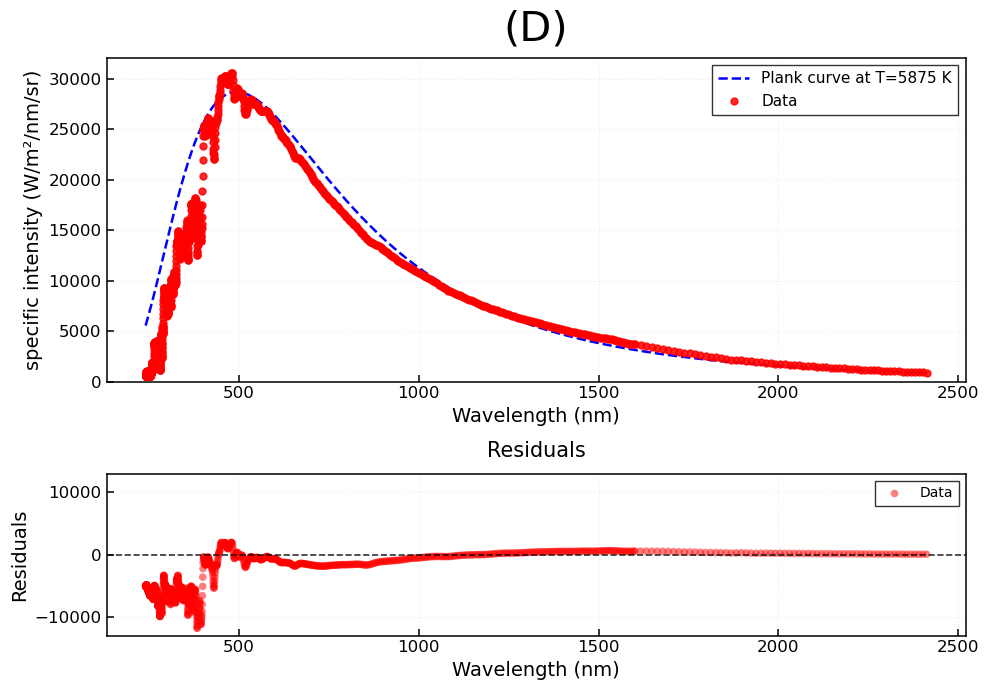

In [42]:
_, fig_4 = blackbody_temperature_comparison_with_errors(
    dfs=[data],
    x_col='wavelength',
    y_col='specific_intensity',
    yerr=None,
    xlabel="Wavelength (nm)",
    ylabel=r"specific intensity (W/m²/nm/sr)",
    title='(D)',
    labels=['Data'],
    colors=['red'],
    temperature=5875,
    title_fontsize=30
)

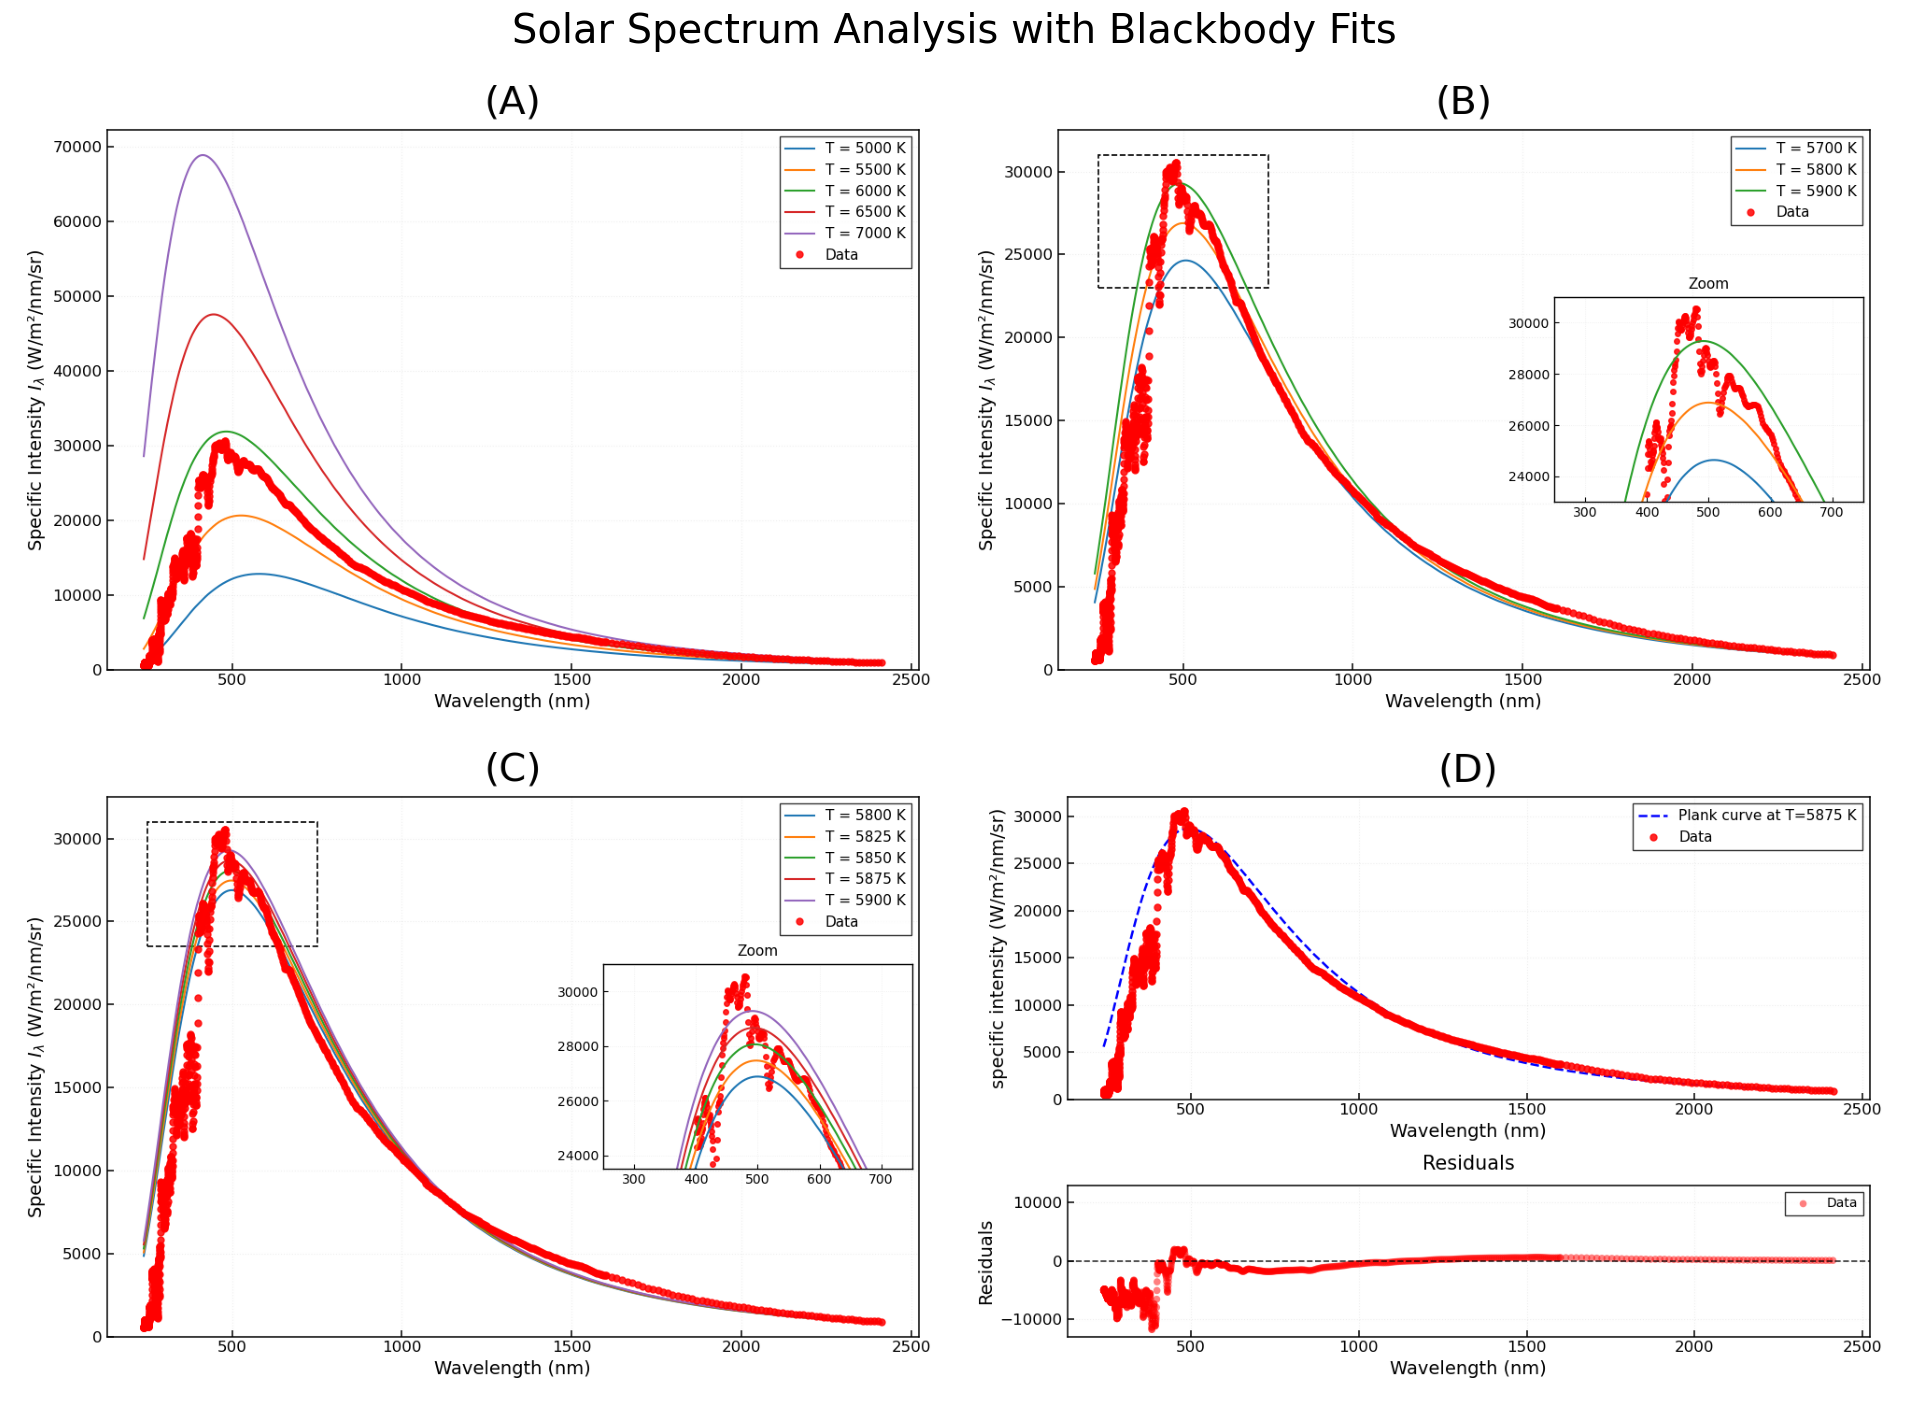

In [43]:
figs = [fig_1, fig_2, fig_3, fig_4]

fig_grid, axes = plt.subplots(2, 2, figsize=(16, 12), dpi=120)
axes = axes.ravel()

for i, (ax, fig) in enumerate(zip(axes, figs), start=1):
    fig.canvas.draw()
    img = np.asarray(fig.canvas.buffer_rgba())
    ax.imshow(img)
    #ax.set_title(f'Figure {i}', fontsize=12)
    ax.axis('off')

for ax in axes[len(figs):]:
    ax.axis('off')

fig_grid.suptitle('Solar Spectrum Analysis with Blackbody Fits', fontsize=24)

fig_grid.tight_layout()
plt.show()


Taking into account the last figure the color tempertature of the sun is $T=5875K$, considering that the plank-curve should touch the maximun of the data it will sugest a value higher than $5900K$ as it can be seen on (B) but carefull observation reveals that those curves don't cross the data previus to the maximun that is another requieremnt, with this in mind a temperature that aproaches as much as it can to the maximun while also crosing at least one data point before the maximun seems optimal, and that tempertaure is $5875K$ as it is seen on (C), morover on (D) a fit with only that temperature shows that is a relative good fit with some residuals probably because of noise that is prety much present on the SORCE mission.

## 5. Con el dato espectral en flujo monocromático, integrando sobre todo el rango espectral medido, obtiene un valor de flujo integrado. Compare dicho valor con el reportado para la fecha por el instrumento SORCE/TIM (Total Irradiance Monitor). Como el flujo integrado decae con el inverso del cuadrado de la distancia, para la fecha dada, corrija por la distancia teniendo en cuenta el radio solar y la distancia Sol-Tierra de la fecha, para obtener así el flujo integral integrado de la radiación emitida en la superficie solar. Con dicho valor, calcule la temperatura efectiva del Sol.

In [61]:
from scipy.integrate import trapezoid

x = data['wavelength'].values
y = data['irradiance'].values

real_distance = 0.994 #AU

computed_tsi = trapezoid(y, x)
computed_tsi = computed_tsi * (1/real_distance**2)
computed_tsi


np.float64(1337.8711095974197)

the integrated flux or irradiance is cumputed ussing the trapezoid rule as the data is prety noisy and is corrected for the distance to the earth on the precise day of the anlisis $0.994$, taking into acount that $F \propto \frac{1}{r^2}$

In [59]:
tsi = pd.read_csv(
    "data/sorce_tsi_L3_c24h_latest.txt",
    comment=';',
    sep=r'\s+',
    header=None,
    names=[
        'date_yyyymmdd', 'date_jdn', 'avg_date_jdn', 'std_date',
        'tsi_1au', 'accuracy_1au', 'precision_1au', 'solar_std_1au', 'uncertainty_1au',
        'tsi_earth', 'accuracy_earth', 'precision_earth', 'solar_std_earth', 'uncertainty_earth',
        'provisional_flag'
    ]
)

reported_value_tsi =  tsi.loc[tsi['date_jdn'] == selected_time_jd]['tsi_1au'].values[0]

tsi.loc[tsi['date_jdn'] == selected_time_jd]



,date_yyyymmdd,date_jdn,avg_date_jdn,std_date,tsi_1au,accuracy_1au,precision_1au,solar_std_1au,uncertainty_1au,tsi_earth,accuracy_earth,precision_earth,solar_std_earth,uncertainty_earth,provisional_flag
1340,20061027.5,2454036.0,2.454036e+06,0.3,1360.8207,0.479,0.0068,0.06098,0.4829,1377.7897,0.485,0.0068,0.2701,0.5551,0


In [ ]:
reported_value_tsi 

np.float64(1360.8207)

In [83]:
print(f'normalized to 1AU')
print(f"Computed integrated Flux from spectrum: {computed_tsi:.1f} W/m²")
print(f"Reported integrated Flux from SORCE: {reported_value_tsi:.1f} W/m²")

normalized to 1AU
Computed integrated Flux from spectrum: 1337.9 W/m²
Reported integrated Flux from SORCE: 1360.8 W/m²


The integrated flux or integrated irradiance computed by ussing the trapezoid rule give a value prety close to the one reported ofitially by the SORCE/TSI mision this is because the last one consider more wavelengths ussing other instruments, but the discrepancy is low so no further refination is needed, also as the TSI makes its calculation ussing 

In [87]:
flux = computed_tsi * ((au**2)/(solar_radius**2))

computed_temperature = np.power(flux/sigma,0.25)
print(f"Computed effective temperature: {computed_temperature:.1f} K")

Computed effective temperature: 5747.1 K


The computed efective temperature is $T=5747.1K$, close to the $T=5875K$ reported previously, dispite both of them ussing the same theorical bases is expected to have some discrepancies as some methods are more reselient that others. considering that ocirding to springer[2] the efective temperature of the sun is $T=5778K$, it can be said that the estimation via the integrated flux was more acurate probably because the trapezoid rule is more resilient to noise in comparison to the empiric fit of the plank curve, but overall both methods manage to get pretty close  

# bibliography

[1] J. Harder (2020), SORCE SIM Level 3 Solar Spectral Irradiance Daily Means V027, Greenbelt, MD, USA, Goddard Earth Sciences Data and Information Services Center (GES DISC), Accessed: [Accessed: Apr. 18, 2026], 10.5067/LDDKZ3PXZZ5G

[2] The Sun: An Introduction | Springer Nature Link. Springer, p. 10. [En línea]. Disponible: https://link.springer.com/book/10.1007/978-3-642-56042-2. [Accessed: Apr. 19, 2026].